# **EDA & Data Perparation**


**Covering:**

* EDA Analysis
* Data verification
* Cleaning
* Profit/Margin
* Inventory-linked risk analysis
* validation check against the known stockout/slow-mover labels

 ## **Day 01 - EDA Analysis & Data Verification**

**Loading Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os

import warnings
warnings.filterwarnings("ignore")

**Loading Dataset**

In [ ]:

# # **Day 01 - Data Preparation & EDA (Updated: FORESIGHT dataset)**from collections import defaultdict
# import kagglehub

# path = kagglehub.dataset_download("mrayyanshehzad/synthetic-retail-dataset-10-million-transactions")

# print("Path to dataset files:", path)


# files = os.listdir(path)
# print("\nParent Folder contain files:", files)
# # Update File Name to select which File to Load
# if 'retail_contaminated_dataset' in files:
#     path = os.path.join(path, 'retail_contaminated_dataset')
#     files = os.listdir(path)
#     print("Sub-folder contain files:", files)

# csv_files = []

# for f in files:
#   if f.endswith(".csv"):
#      csv_files.append(f)

# print("\nCSV files in the folder:", csv_files)


# df = {}

# for file in csv_files:
#     file_path = os.path.join(path, file)

#     df_name = file.replace('.csv', '')
#     df[df_name] = pd.read_csv(file_path)
#     print(f"Loaded: {file} as dataframes['{df_name}'] (Shape: {df[df_name].shape})")

**Data Loading from Local System**

In [2]:
# import  zipfile

# base_path = r"Datasets\retail_contaminated_dataset.zip"

# with zipfile.ZipFile(base_path, 'r' ) as zip_ref:
#     zip_ref.extractall(r"Datasets\extracted_files")


files = os.listdir(r"Datasets\extracted_files")
print("Files:", files)

csv_files = [f for f in files if f.endswith(".csv")]

df = {}
for file in csv_files:
    file_path = os.path.join(r"Datasets\extracted_files", file)
    df_name = file.replace('.csv', '')
    
    df[df_name] = pd.read_csv(file_path)
    print(f"Loaded: {file} (Shape: {df[df_name].shape})")

Files: ['customer_master.csv', 'inventory_snapshot.csv', 'processed_sales_transactions.parquet', 'promotions.csv', 'sales_transactions.csv', 'sku_inventory_flags.csv', 'sku_master.csv', 'store_master.csv']
Loaded: customer_master.csv (Shape: (10000, 7))
Loaded: inventory_snapshot.csv (Shape: (26408, 6))
Loaded: promotions.csv (Shape: (100, 8))
Loaded: sales_transactions.csv (Shape: (9945511, 11))
Loaded: sku_inventory_flags.csv (Shape: (600, 6))
Loaded: sku_master.csv (Shape: (5000, 7))
Loaded: store_master.csv (Shape: (30, 5))


**Dataset Loading Flow**

```
📁 /kaggle/input/synthetic-retail-dataset-10-million-transactions (Main Path)
│
├── 📑 README.md
└── 📁 Synthetic Retail Dataset/  <-- [Line: if 'Synthetic Retail Dataset' in files]
    │                                  Enter inside this folder to access .csv files
    ├── 📄 sales_transactions.csv
    ├── 📄 sku_inventory_flags.csv
    ├── 📄 inventory_snapshot.csv
    ├── 📄 store_master.csv
    ├── 📄 customer_master.csv
    ├── 📄 sku_master.csv
    └── 📄 promotions.csv
    
```

**Dataset Relationship**
```
store_master.store_id      ──┐
sku_master.sku_id           ─┼──▶ sales_transactions.csv
customer_master.cust_id     ─┤     (store_id, sku_id, customer_id, promo_id)
promotions.promo_id         ─┘

store_master.store_id   ──┐
sku_master.sku_id        ─┴──▶ inventory_snapshot.csv

sku_master.sku_id  ──▶ sku_inventory_flags.csv   (GROUND-TRUTH labels — do NOT use as a feature,
                                                    only to validate our own risk logic later)
```

### **Step 1 — EDA Analysis**


**Data View, Shape & Columns**

In [3]:
for name, table in df.items():
    print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
    print(f" {name}")
    print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
    display(table.head(3))
    print("shape:", table.shape)
    print("columns:", list(table.columns))
    print()

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 customer_master
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,cust_id,age,gender,city,loyalty_segment,preferred_channel,registration_date
0,CUST00001,52,Female,Sukkur,Silver,Online,2021-01-01
1,CUST00002,41,Female,Karachi,Silver,Mobile App,2021-05-14
2,CUST00003,48,Female,Bahawalpur,Bronze,In-Store,2022-10-23


shape: (10000, 7)
columns: ['cust_id', 'age', 'gender', 'city', 'loyalty_segment', 'preferred_channel', 'registration_date']

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 inventory_snapshot
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,333,72,22,2025-06-23
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,496,96,34,2025-07-10


shape: (26408, 6)
columns: ['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 promotions
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


...

shape: (600, 6)
columns: ['sku_id', 'flag', 'affected_stores', 'window_start', 'window_end', 'notes']

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 sku_master
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch


shape: (5000, 7)
columns: ['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price', 'cost_price', 'brand']

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 store_master
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,store_id,store_name,city,store_type,opening_date
0,ST01,Quetta Convenience Store #01,Quetta,Convenience Store,2017-07-08
1,ST02,Islamabad Express Store #02,Islamabad,Express Store,2019-05-08
2,ST03,Sialkot Supermarket #03,Sialkot,Supermarket,2019-03-28


shape: (30, 5)
columns: ['store_id', 'store_name', 'city', 'store_type', 'opening_date']



 **Data Info & Describe**

In [4]:
for name, table in df.items():
    print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
    print(f" {name}")
    print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
    display(table.info())
    display(table.describe())
    print("---------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
    
    

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 customer_master
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   cust_id            10000 non-null  str  
 1   age                10000 non-null  int64
 2   gender             10000 non-null  str  
 3   city               10000 non-null  str  
 4   loyalty_segment    10000 non-null  str  
 5   preferred_channel  10000 non-null  str  
 6   registration_date  10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 990.8 KB


None

,age
count,10000.000000
mean,37.702900
std,12.190106
min,18.000000
25%,29.000000
50%,37.000000
75%,46.000000
max,80.000000


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 inventory_snapshot
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 26408 entries, 0 to 26407
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   store_id           26408 non-null  str  
 1   sku_id             26408 non-null  str  
 2   stock_on_hand      26408 non-null  int64
 3   reorder_point      26408 non-null  int64
 4   safety_stock       26408 non-null  int64
 5   last_restock_date  26408 non-null  str  

None

...

,unit_price,cost_price
count,5000.000000,5000.000000
mean,619.191672,417.040736
std,708.009319,480.347009
min,24.410000,16.750000
25%,160.555000,108.825000
50%,318.745000,214.670000
75%,788.715000,530.027500
max,4755.470000,3398.160000


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 store_master
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   store_id      30 non-null     str  
 1   store_name    30 non-null     str  
 2   city          30 non-null     str  
 3   store_type    30 non-null     str  
 4   opening_date  30 non-null     str  
dtypes: str(5)
memory usage: 3.1 KB


None

,store_id,store_name,city,store_type,opening_date
count,30,30,30,30,30
unique,30,30,12,4,30
top,ST01,Quetta Convenience Store #01,Karachi,Convenience Store,2017-07-08
freq,1,1,5,11,1


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------


**Exploring Datasets**

> As our main file is sales_transaction so we focuses on that.

In [5]:
df['sales_transactions'].dtypes

date                str
receipt_id          str
store_id            str
sku_id              str
customer_id         str
quantity          int64
unit_price      float64
total_value     float64
channel             str
discount_pct    float64
promo_id            str
dtype: object

In [6]:
df_sales = df['sales_transactions'].iloc[:300000]

In [8]:
columns = ['quantity', 'unit_price', 'total_value', 'discount_pct']

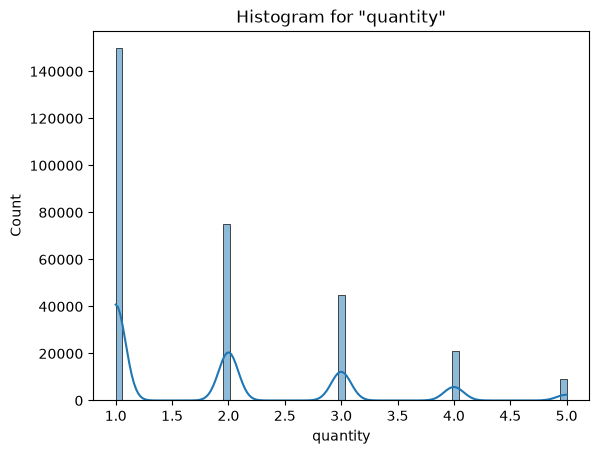

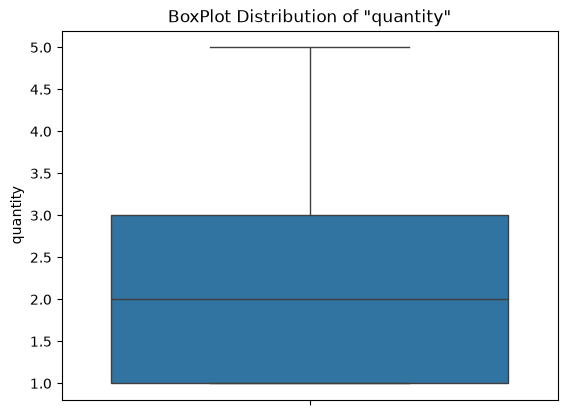

-------------------------------------------------------------------------------------------


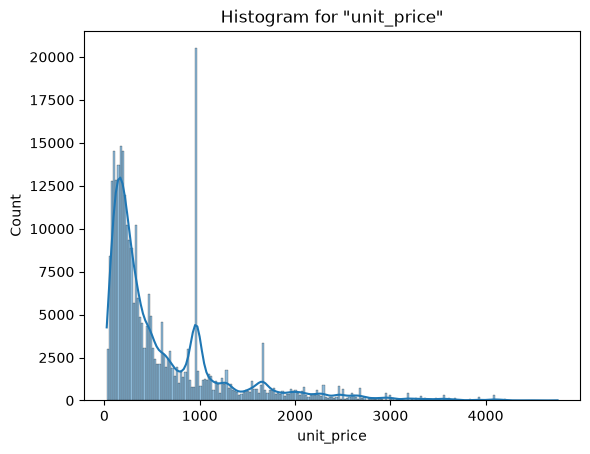

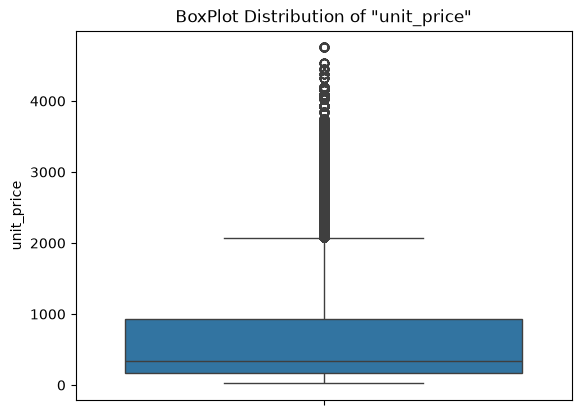

-------------------------------------------------------------------------------------------


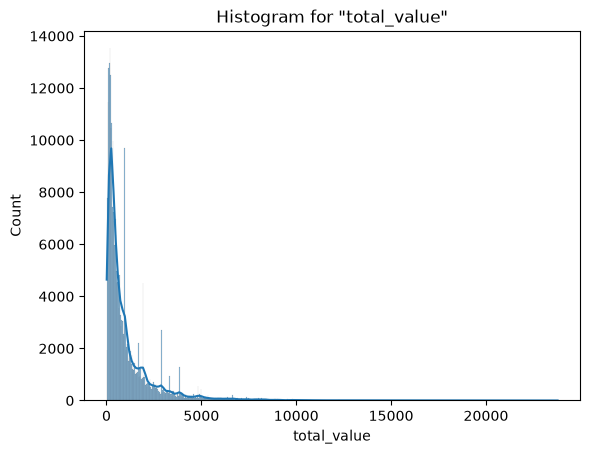

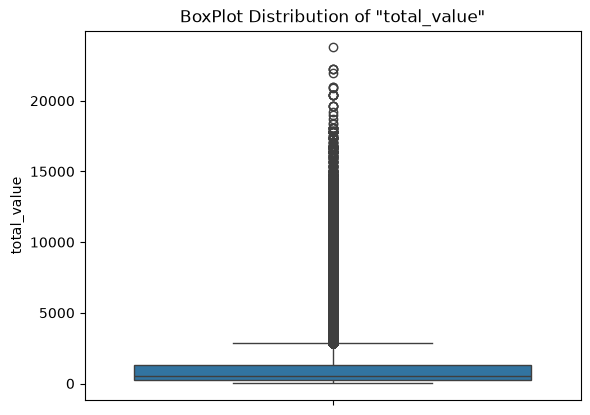

-------------------------------------------------------------------------------------------


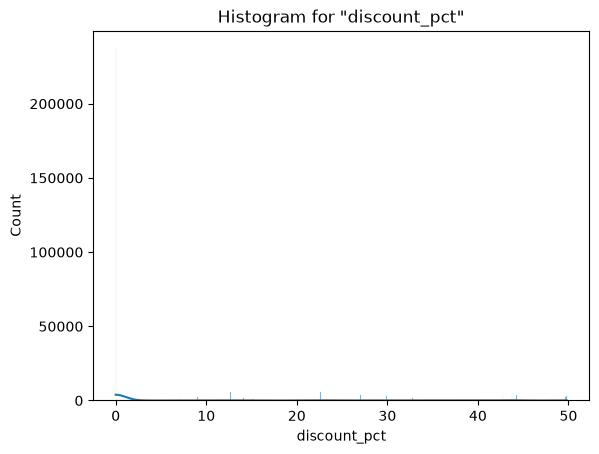

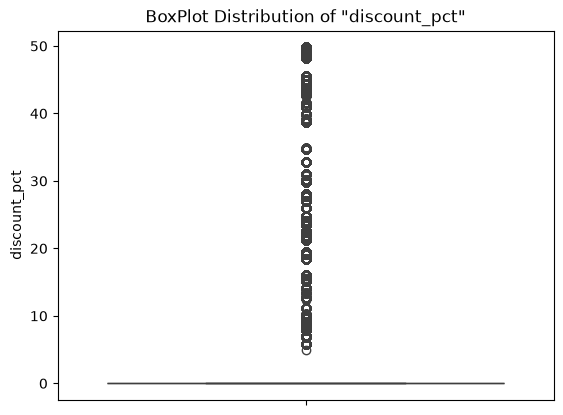

-------------------------------------------------------------------------------------------


In [9]:
for col in columns:
    # 1. Histogram
    sns.histplot(data=df_sales, x=col,kde=True)
    plt.title(f"Histogram for \"{col}\"")
    plt.show()  

    # 2. Boxplot
    sns.boxplot(data=df_sales, y=col)
    # plt.yscale("log") 
    plt.title(f"BoxPlot Distribution of \"{col}\"")
    plt.show() 

    print(
        "-------------------------------------------------------------------------------------------"
    )

### **Step 2 — Verification (before manipulating data)**


**Primary Data Verification**

In [10]:
expected_rows = {
    "store_master": 30,
    "sku_master": 5000,
    'customer_master': 10000,
    'promotions': 100,
}

for name, expected in expected_rows.items():
    actual = len(df[name])
    # status = "OK" if actual == expected else "MISMATCH"
    status = "Unknown"
    if actual == expected:
      status = "OK"
      print(f"{name:20s}   actual={actual:>7}   expected={expected:>7}   [{status}]")
    elif actual > expected:
      status = "EXCESS"
      print(f"{name:20s}   actual={actual:>7}   expected={expected:>7}  [{status}]")
    else:
      status = "MISMATCH"
      print(f"{name:20s}   actual={actual:>7}   expected={expected:>7}  [{status}]")

store_master           actual=     30   expected=     30   [OK]
sku_master             actual=   5000   expected=   5000   [OK]
customer_master        actual=  10000   expected=  10000   [OK]
promotions             actual=    100   expected=    100   [OK]


**Secondary Data Verification**

In [11]:
print(f"{'inventory_snapshot':20s}   actual={len(df['inventory_snapshot']):>8}   expected= no fixed target (quick-check only)")
print(f"{'sales_transactions':20s}   actual={len(df['sales_transactions']):>8}   expected= 10 Million")
print(f"{'sku_inventory_flags':20s}   actual={len(df['sku_inventory_flags']):>8}   expected= 600 (200 STOCKOUT_RISK + 400 SLOW_MOVER)")


inventory_snapshot     actual=   26408   expected= no fixed target (quick-check only)
sales_transactions     actual= 9945511   expected= 10 Million
sku_inventory_flags    actual=     600   expected= 600 (200 STOCKOUT_RISK + 400 SLOW_MOVER)


In [12]:
print(df['sku_inventory_flags']['flag'].value_counts())

flag
SLOW_MOVER       400
STOCKOUT_RISK    200
Name: count, dtype: int64


**Master tables `primary key` uniqueness check**

In [13]:
primary_key = {
    "store_master": "store_id",
    "sku_master": "sku_id",
    'customer_master': "cust_id",
    'promotions': "promo_id",
}

for name, key in primary_key.items():
    duplicates = df[name][key].duplicated().sum()
    print(f"{name:20s}   duplicates={duplicates:>3}")



store_master           duplicates=  0
sku_master             duplicates=  0
customer_master        duplicates=  0
promotions             duplicates=  0


**Referential integrity**
 > every FK in sales/inventory must exist in its master table

In [14]:
checks = [
    #(child table) (child key) (parent table) (parent key)
    ("sales_transactions", "store_id", "store_master", "store_id"),
    ("sales_transactions", "sku_id", "sku_master", "sku_id"),
    ("sales_transactions", "customer_id", "customer_master", "cust_id"),
    ("inventory_snapshot", "store_id", "store_master", "store_id"),
    ("inventory_snapshot", "sku_id", "sku_master", "sku_id"),
]

for child_table, child_key, parent_table, parent_key in checks:

  child_values = df[child_table][child_key]
  parent_values = df[parent_table][parent_key]

  valid = child_values.isin(parent_values).all()

  # print(f"{child_table}.{child_key:13s} -> \t {parent_table}.{parent_key}: {'OK' if valid else 'MISMATCH':}")

  child_full = f"{child_table}.{child_key}"
  parent_full = f"{parent_table}.{parent_key}"
  status = 'OK' if valid else 'MISMATCH'

  print(f"{child_full:32s} ->    {parent_full:26s} :    {status}")


sales_transactions.store_id      ->    store_master.store_id      :    OK
sales_transactions.sku_id        ->    sku_master.sku_id          :    OK
sales_transactions.customer_id   ->    customer_master.cust_id    :    OK
inventory_snapshot.store_id      ->    store_master.store_id      :    OK
inventory_snapshot.sku_id        ->    sku_master.sku_id          :    OK


`promo_id` is allowed to be null (no promotion applied) — check only the non-null ones

In [15]:
promo_values = df['sales_transactions']['promo_id'].dropna()

valid = promo_values.isin(df['promotions']['promo_id']).all()
print(f"sales_transactions.promo_id (non-null) -> promotions.promo_id: {'OK' if valid else 'MISMATCH'}")


sales_transactions.promo_id (non-null) -> promotions.promo_id: OK
